# Análisis Exploratorio de Datos — NeuroInsight (TFM)

Este notebook cubre la sección 4.2 de la memoria (EDA) sobre el dataset real de ADNI,
más la clusterización no supervisada (4.3.1). Reutiliza las mismas funciones de
`eda.py`, `datos.py` y `clustering.py` que usa `main.py` para el pipeline completo —
aquí se llaman una a una, con comentario alrededor, para poder revisar cada resultado
según va saliendo, en vez de solo ver el resumen final por consola.

La comparación de modelos (XGBoost frente a otras 4 alternativas) vive en
`comparacion_modelos.py`, no aquí: ese análisis no es exploratorio, es la evaluación
de los modelos ya entrenados (sección 4.3.2 de la memoria).

## Terminología

Antes de entrar en los datos, un glosario breve de los términos clínicos que aparecen
en todo el notebook:

- **MMSE** (Mini-Mental State Examination): prueba cognitiva breve, puntuada de 0 a 30.
  Es, con diferencia, la variable de mayor peso en el modelo final (sección 4.4 de la memoria).
- **APOE4**: variante del gen APOE (episilon-4). Tener al menos una copia se asocia a
  mayor riesgo de Alzheimer en la población general, aunque en este dataset concreto
  pesa poco (ver sección 4.4 — es sobre todo un marcador de inicio tardío, y ADNI es
  una cohorte poblacional general).
- **Volumen hipocampal**: tamaño del hipocampo (mm³), medido por resonancia magnética.
  El hipocampo es una de las primeras estructuras cerebrales que se atrofia en el
  Alzheimer, así que un volumen menor es indicativo de deterioro.
- **Tau y Abeta42 (LCR)**: proteínas medidas en el líquido cefalorraquídeo (mediante
  punción lumbar). Tau elevada y Abeta42 baja son ambos indicadores clásicos de
  patología de Alzheimer.
- **p-Tau217 y ratio Aβ42/Aβ40 (plasma)**: versiones más recientes de los mismos
  biomarcadores, medidas en sangre en vez de LCR — menos invasivas, pero con menor
  cobertura en el dataset (sección de completitud, más abajo).
- **CN / MCI / AD**: las tres categorías diagnósticas del modelo — Cognitivamente
  Normal, Deterioro Cognitivo Leve (Mild Cognitive Impairment) y Enfermedad de
  Alzheimer (Alzheimer's Disease), en orden de menor a mayor deterioro.
- **ADNI**: Alzheimer's Disease Neuroimaging Initiative, el estudio longitudinal del
  que proceden todos los datos usados aquí (adni.loni.usc.edu).

## Preparación

Carga las librerías propias del proyecto y de los datos reales. Si no encuentra los
CSV de ADNI en `data/raw/`, en `RUTA_ADNI` y `RUTA_PLASMA` puedes ajustarlos.

In [2]:
import sys
from pathlib import Path
from IPython.display import Image, display

RAIZ_PROYECTO = Path.cwd().resolve().parent.parent.parent  # notebooks/ -> modelado -> src -> raíz del proyecto
sys.path.insert(0, str(RAIZ_PROYECTO / "src" / "modelado"))

import pandas as pd

from datos import cargar_datos_reales
from eda import (
    resumen_estadistico, completitud_variables,
    graficar_distribuciones, graficar_completitud, graficar_tendencia_mmse,
    CARPETA_RESULTADOS_DEFECTO,
)
from clustering import ejecutar_clustering, graficar_clusters

RUTA_ADNI = RAIZ_PROYECTO / "data" / "raw" / "ADNIMERGE_11Aug2026.csv"
RUTA_PLASMA = RAIZ_PROYECTO / "data" / "raw" / "UPENN_PLASMA_FUJIREBIO_QUANTERIX_11Aug2026.csv"

df = cargar_datos_reales(str(RUTA_ADNI), fuente="adni", ruta_plasma=str(RUTA_PLASMA))
df = df[df["diagnostico"] != "Desconocido"].copy()
print(f"{len(df)} pacientes con diagnóstico válido")

ModuleNotFoundError: No module named 'pandas'

## 1. Distribución de diagnósticos y estadísticos descriptivos

Goal: cuántos pacientes hay de cada diagnóstico, y los
estadísticos básicos (media, desviación, min/max) de cada variable numérica.

In [1]:
_ = resumen_estadistico(df)

df.columns

NameError: name 'resumen_estadistico' is not defined

Podemos observar un reparto sin clase claramente minoritaria (46% MCI, 37% CN, 17% AD)

Abordaremos en este Trabajo de Fin de Máster un problema de clasificación de estas tres clases, sin necesidad de
técnicas de balanceo.

## 2. Completitud de variables

Cuántos pacientes tienen cada variable realmente medida (no ausente). Esta tabla es
la que justifica, en la sección 4.3.2 de la memoria, la decisión de no exigir todas
las variables completas (dropna estricto) y dejar que XGBoost maneje los valores
ausentes de forma nativa.

--- Completitud de variables ---
              variable  completitud_%
                  mmse          100.0
                  edad           99.8
         hipocampo_mm3           85.7
             tau_pg_ml           50.2
         abeta42_pg_ml           50.2
  ptau217_plasma_pg_ml           22.9
ratio_ab42_ab40_plasma           22.8
--- Completitud de variables ---
              variable  completitud_%
                  mmse          100.0
                  edad           99.8
         hipocampo_mm3           85.7
             tau_pg_ml           50.2
         abeta42_pg_ml           50.2
  ptau217_plasma_pg_ml           22.9
ratio_ab42_ab40_plasma           22.8
Gráfico guardado en C:\Users\Ana\Documents\Máster\TFM_AD_RISK\resultados\eda_completitud.png


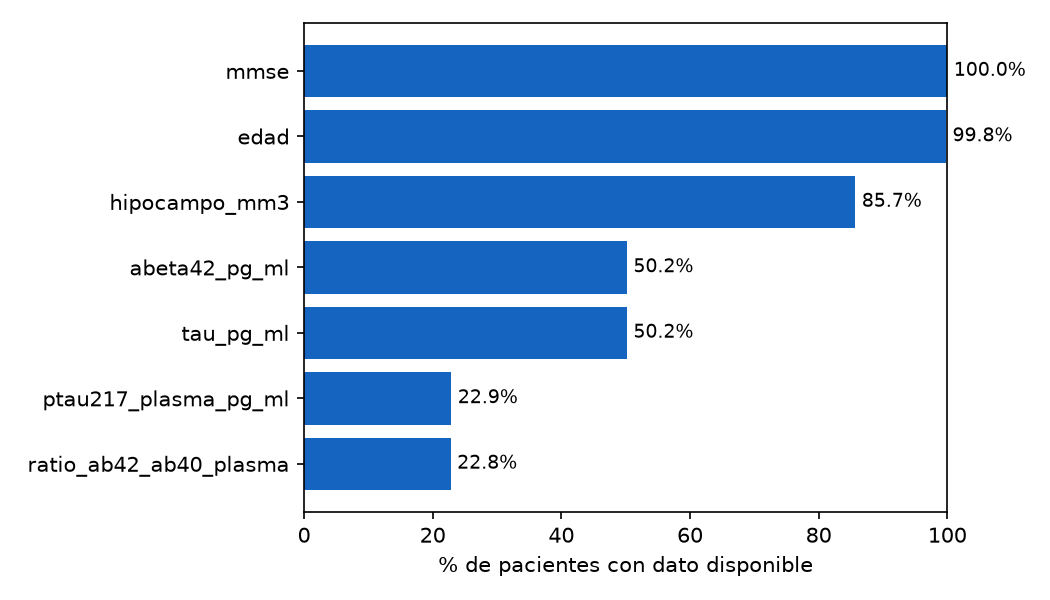

In [3]:
tabla_completitud = completitud_variables(df)
graficar_completitud(df)
display(Image(filename=str(Path(CARPETA_RESULTADOS_DEFECTO) / "eda_completitud.png")))

Vemos que edad y MMSE están prácticamente al 100%; el volumen hipocampal, en torno al
86%; los biomarcadores en LCR, alrededor del 50%; los de plasma, más recientes, por
debajo del 23%. Con estas diferencias, exigir el dato completo en las 8 variables
habría descartado a la mayoría de los pacientes.

## 3. Distribución de las variables clave por diagnóstico

Histogramas de MMSE, Tau, Abeta42 e hipocampo, separados por grupo diagnóstico. El objetivo es 
ver si, a simple vista, las distribuciones ya se separan razonablemente entre
CN, MCI y AD antes incluso de entrenar ningún modelo.

Gráfico guardado en C:\Users\Ana\Documents\Máster\TFM_AD_RISK\resultados\eda_distribuciones.png


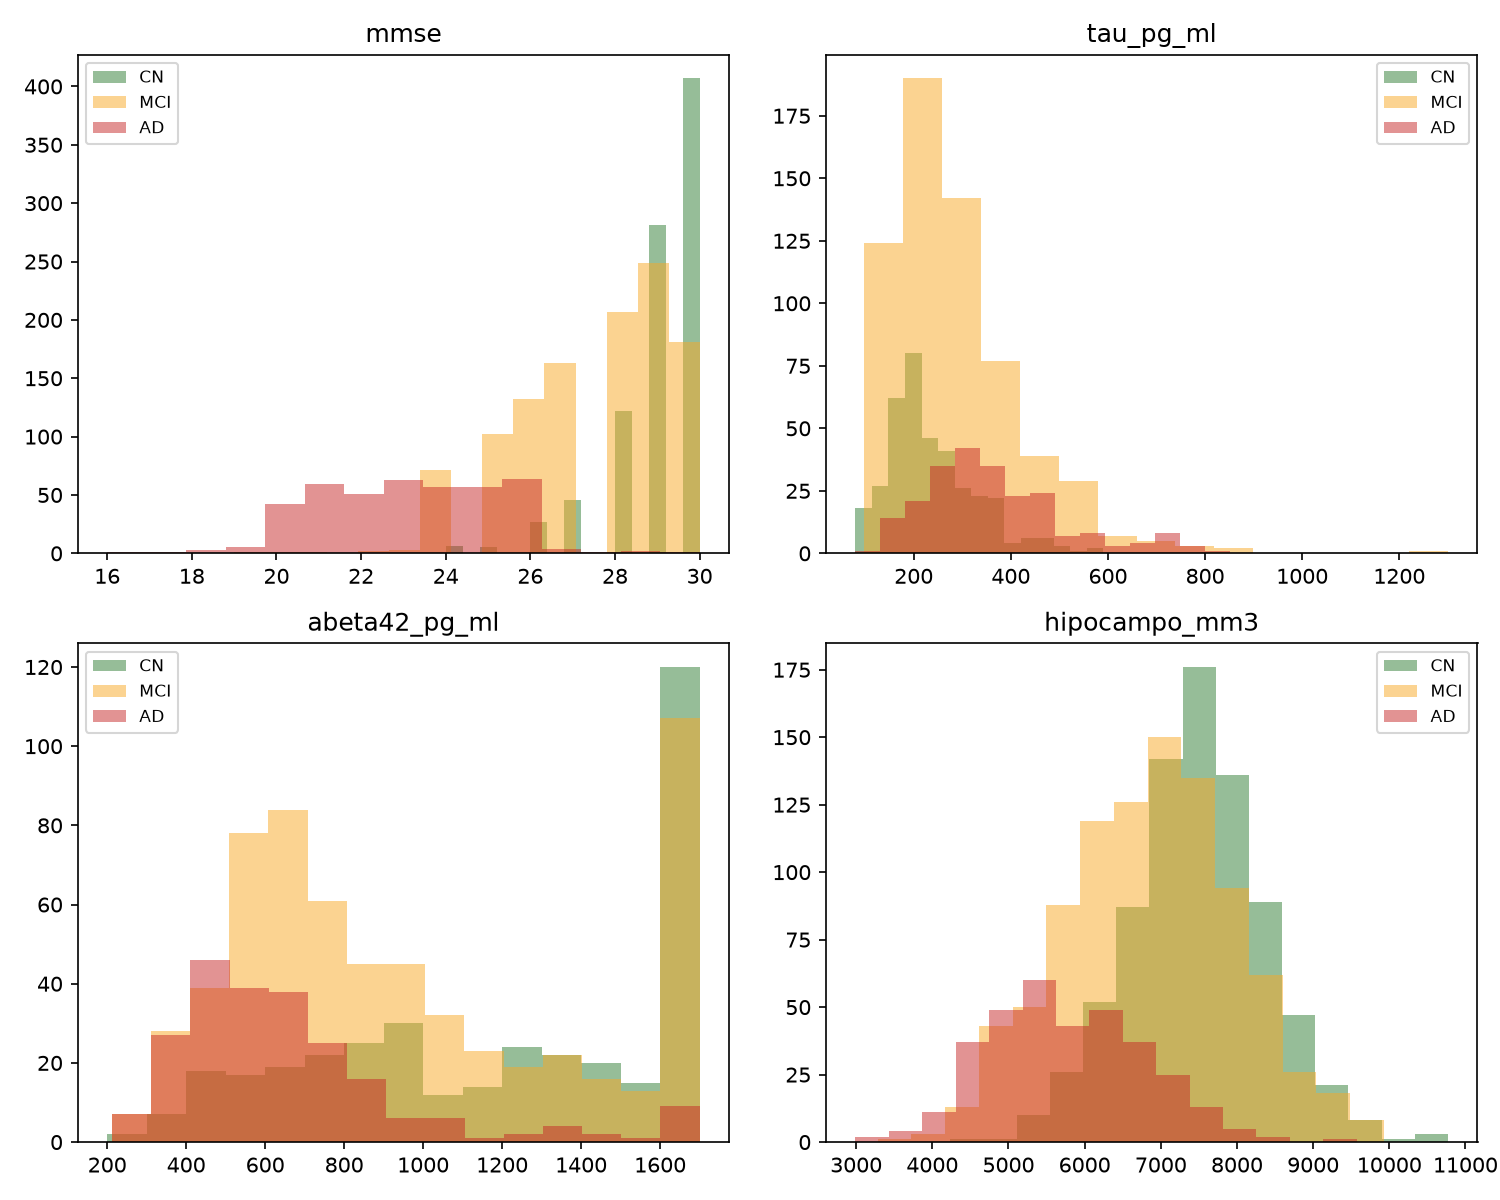

In [4]:
graficar_distribuciones(df)
display(Image(filename=str(Path(CARPETA_RESULTADOS_DEFECTO) / "eda_distribuciones.png")))

Vemos que el MMSE es el que muestra una separación más clara entre grupos. 
Más adelante, veremos que es la variable de mayor peso en el modelo (sección 4.4).
Tau, Abeta42 e hipocampo se solapan bastante más entre grupos, aunque con tendencias
visibles (AD hacia tau más alta y abeta42/hipocampo más bajos).

## 4. Evolución del MMSE a lo largo del seguimiento

A diferencia de las secciones anteriores (todas transversales, un valor por
paciente), aquí se aprovecha que ADNI es un estudio longitudinal: para cada grupo
diagnóstico **basal**, se calcula el MMSE medio observado en las sucesivas visitas de
seguimiento de esos mismos pacientes. Es descriptivo, no una proyección individual;
para eso haría falta un modelo entrenado específicamente para pronosticar
trayectorias (línea futura, sección 6.3 de la memoria).

Gráfico guardado en C:\Users\Ana\Documents\Máster\TFM_AD_RISK\resultados\tendencia_mmse.png


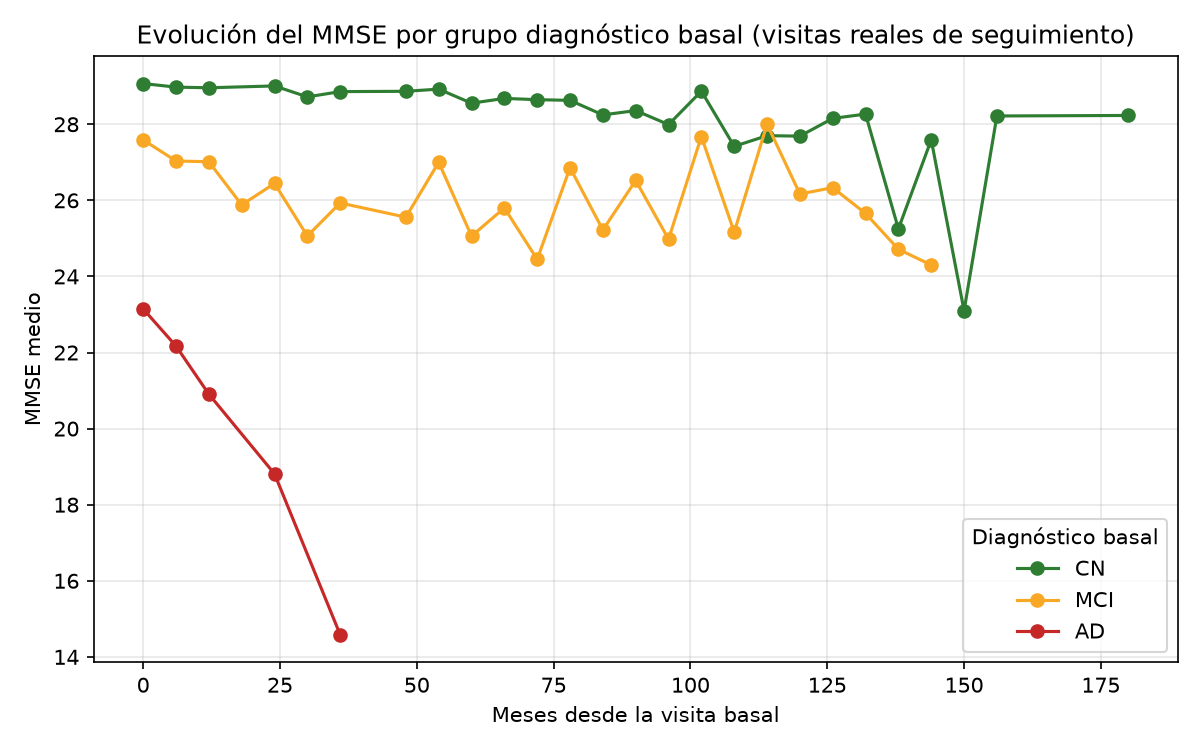

In [5]:
graficar_tendencia_mmse(str(RUTA_ADNI))
display(Image(filename=str(Path(CARPETA_RESULTADOS_DEFECTO) / "tendencia_mmse.png")))

El grupo CN se mantiene estable en torno a 29 puntos; MCI muestra un
descenso moderado; AD muestra un descenso marcado, de 23,1 a 18,8 en apenas 24 meses.
Un patrón clínicamente coherente con lo esperado en cada diagnóstico.

## 5. Clustering (estratificación no supervisada)

KMeans sobre las variables numéricas estandarizadas, proyectado a 2 dimensiones con
UMAP solo para poder visualizarlo — los ejes de la proyección no tienen un
significado propio, lo que importa es la cercanía relativa entre puntos.

c:\Users\Ana\Documents\Máster\TFM_AD_RISK\venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Ana\Documents\Máster\TFM_AD_RISK\venv2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Gráfico guardado en C:\Users\Ana\Documents\Máster\TFM_AD_RISK\resultados\clustering_proyeccion.png


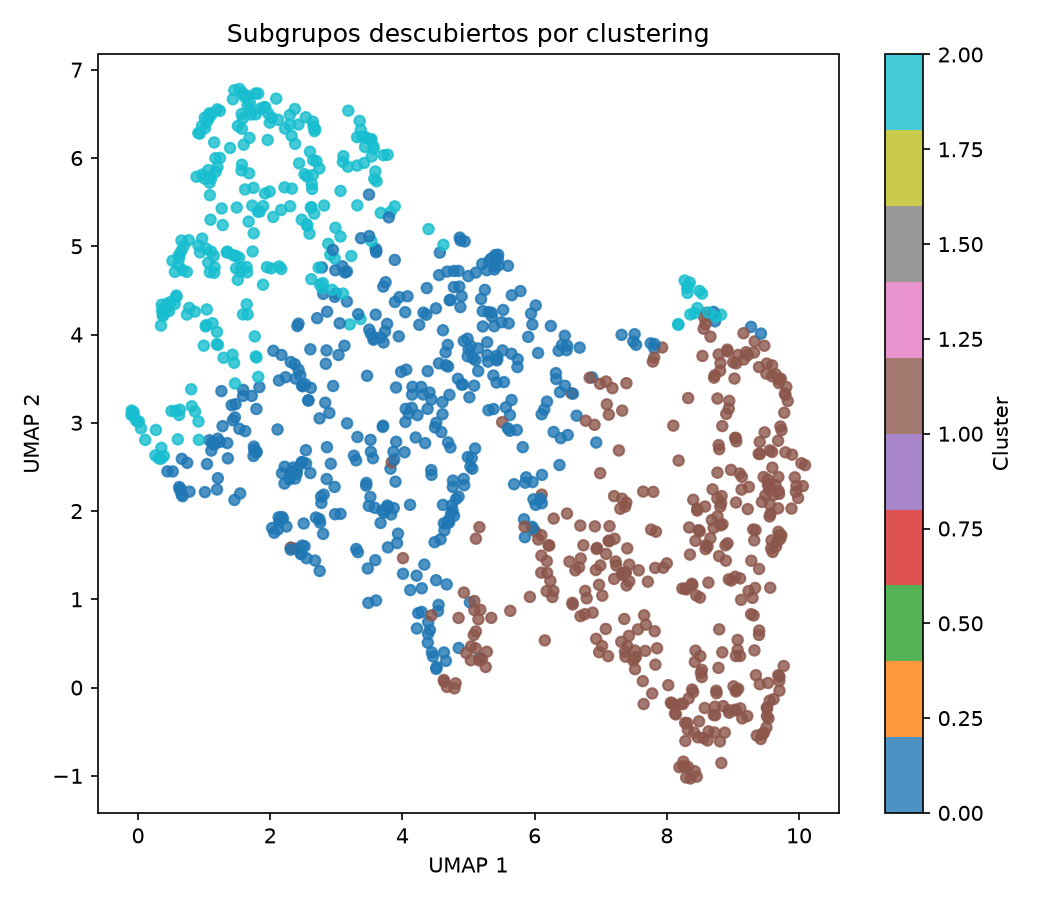

In [6]:
df_clusters = ejecutar_clustering(df)
graficar_clusters(df_clusters)
display(Image(filename=str(Path(CARPETA_RESULTADOS_DEFECTO) / "clustering_proyeccion.png")))

**Lectura**: separación parcial entre subgrupos, con una región de solapamiento
considerable — coherente con que el deterioro cognitivo es un continuo, no
categorías perfectamente discretas en la práctica clínica.

## Resumen

| Sección | Hallazgo principal |
|---|---|
| Distribución | 3 clases sin desbalanceo severo (46/37/17%) |
| Completitud | Huecos muy dispares entre variables (100% a 23%) → justifica manejo nativo de NaN |
| Distribuciones | MMSE separa mejor los 3 grupos que ningún biomarcador aislado |
| Tendencia MMSE | Declive coherente con el diagnóstico basal en las visitas de seguimiento reales |
| Clustering | Subgrupos parcialmente separables, sin fronteras nítidas |

Sigue en `comparacion_modelos.py` (sección 4.3.2) para la comparación de modelos y el
efecto de la calibración de probabilidades.